<a href="https://colab.research.google.com/github/Ayushibansal805/ML_Lab/blob/main/lab_ml6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile("brain_alzheimer.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
#import optimizer and loss function
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_generator = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')
train_data = train_generator.flow_from_directory('/content/Combined Dataset/train',
                                                 target_size=(224, 224),
                                                 batch_size=32,
                                                 class_mode='categorical')

Found 10240 images belonging to 4 classes.


In [ ]:
test_generator = ImageDataGenerator(rescale=1./255)
test_data = test_generator.flow_from_directory('/content/Combined Dataset/test',
                                                 target_size=(224, 224),
                                                 batch_size=32,
                                                 class_mode='categorical')

Found 1279 images belonging to 4 classes.


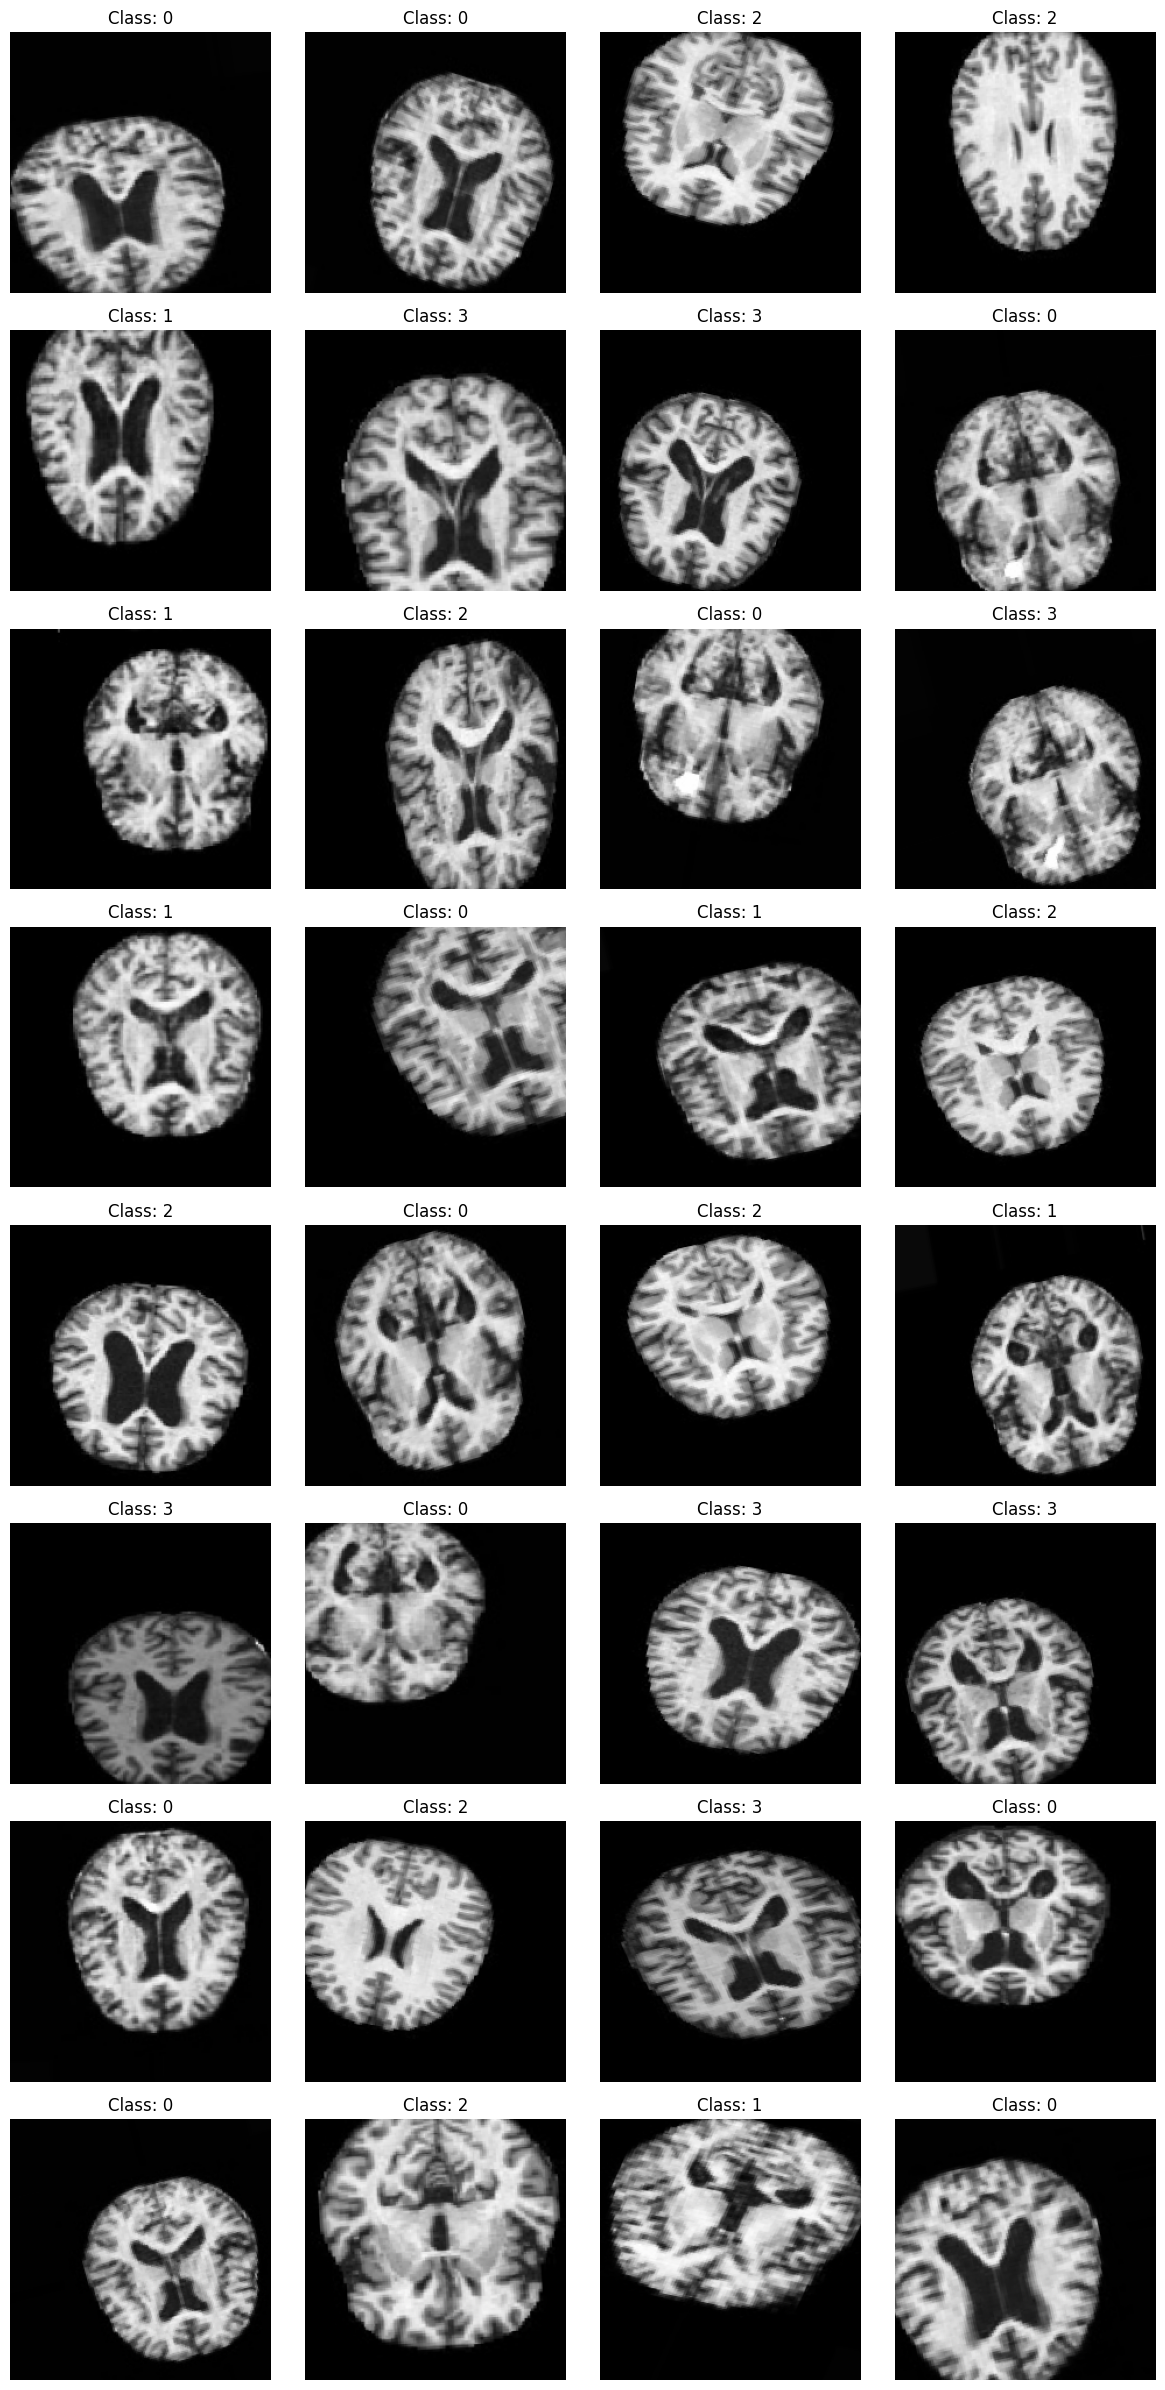

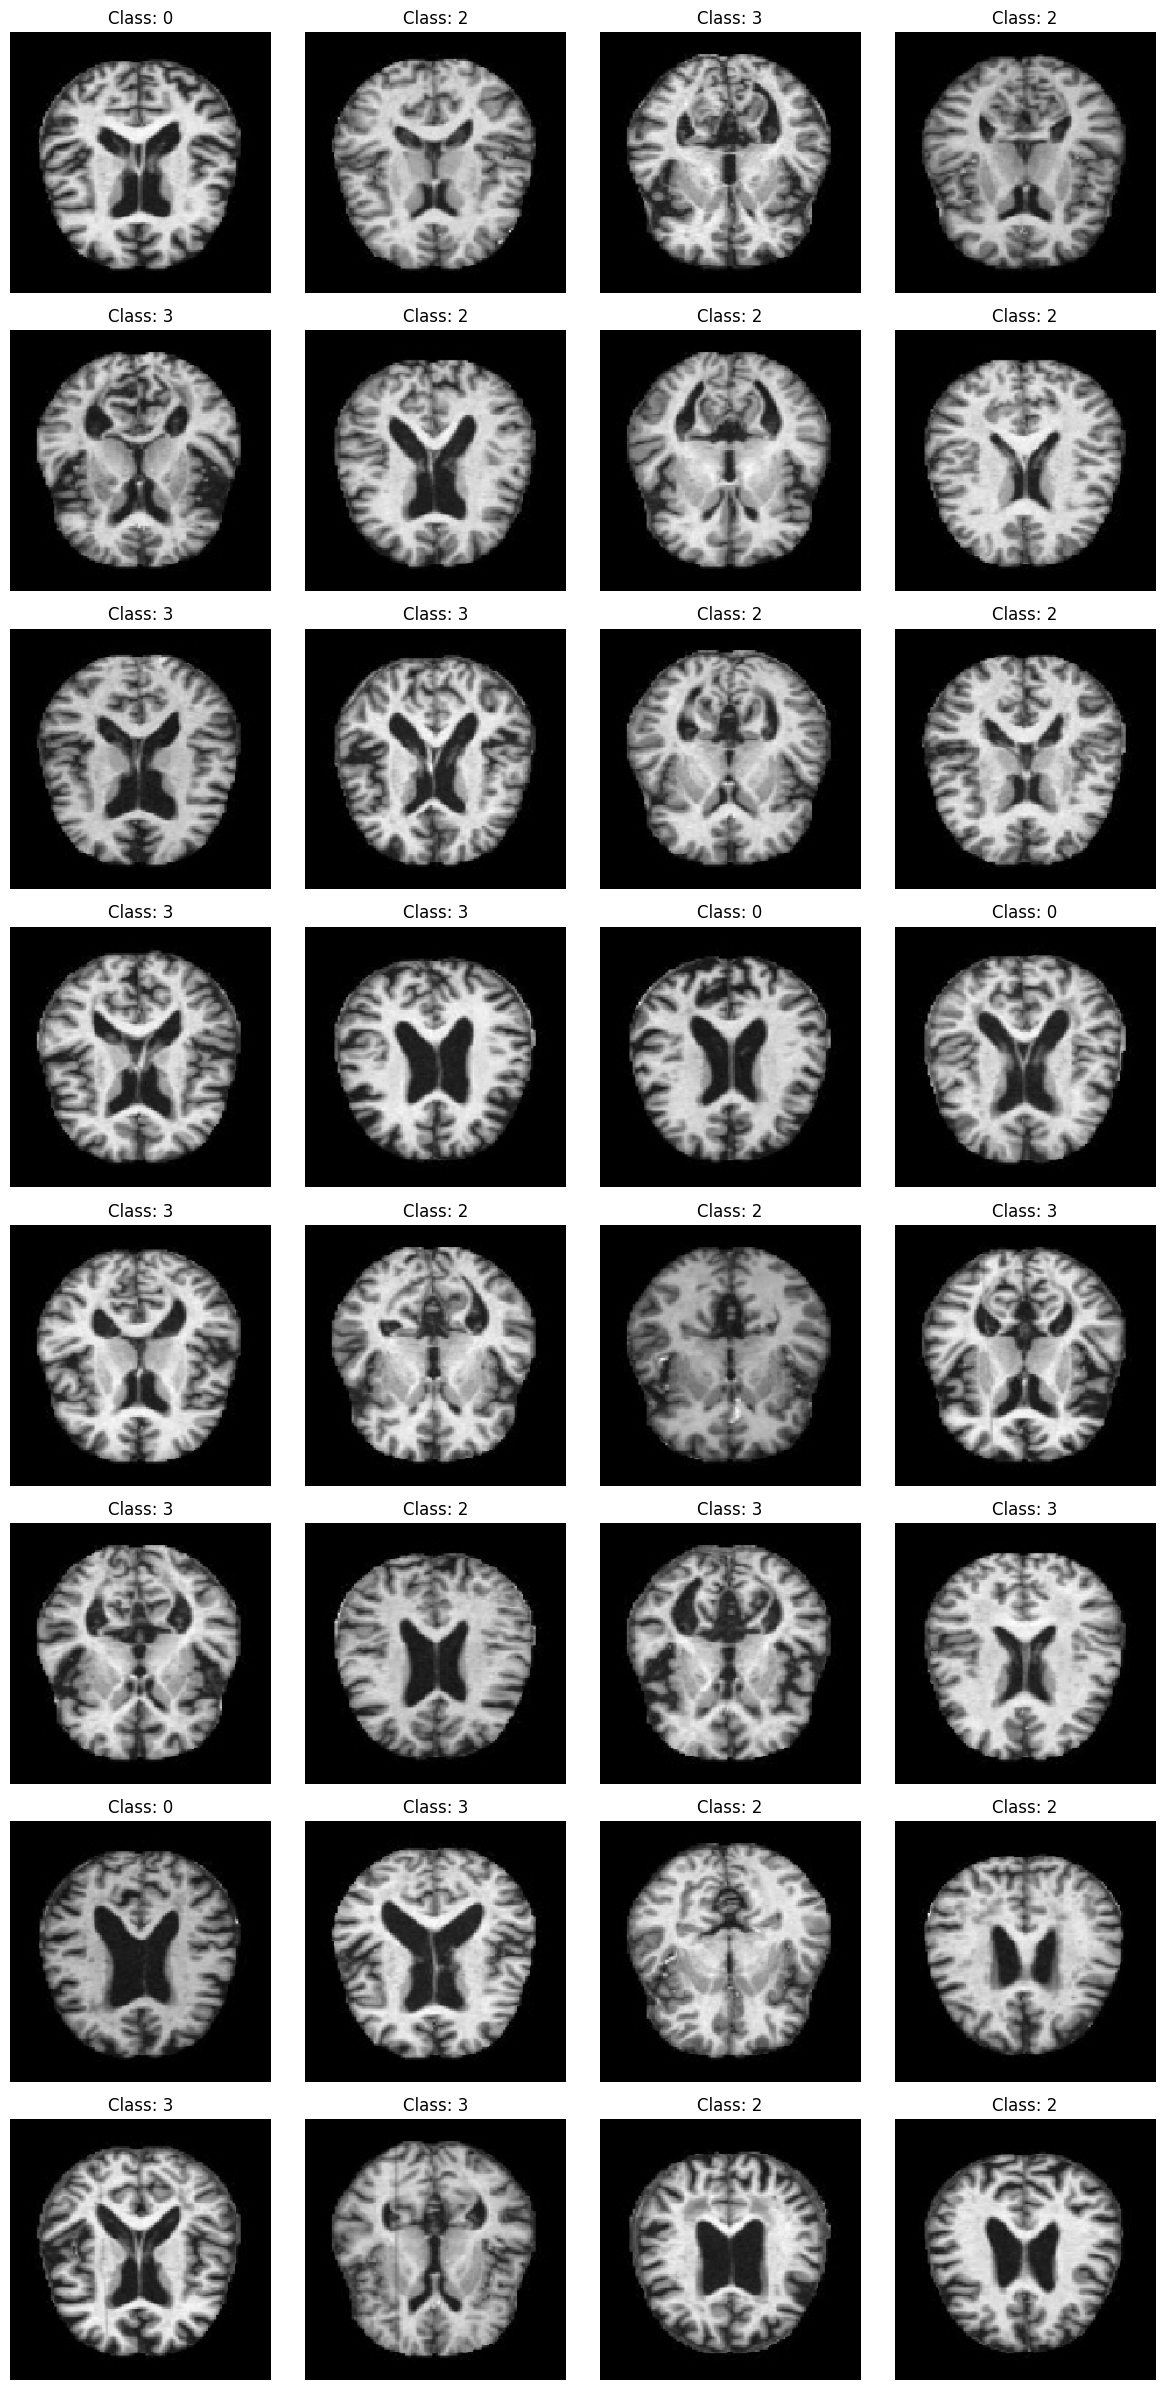

In [ ]:
#@title Plotting an images
import math
# Function to plot images
def plot_images(images, labels):
    num_images = images.shape[0]
    num_rows = int(math.ceil(num_images / 4))
    fig, axes = plt.subplots(num_rows, 4, figsize=(12, 3 * num_rows))
    for i in range(num_images):
        row = i // 4
        col = i % 4
        axes[row, col].imshow(images[i])
        axes[row, col].set_title(f"Class: {np.argmax(labels[i])}")
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()


# Get a batch of training images and labels
train_images, train_labels = next(train_data)

# Get a batch of testing images and labels
test_images, test_labels = next(test_data)

# Plot a few images from the training and testing data
import matplotlib.pyplot as plt
import numpy as np
plot_images(train_images, train_labels)
plot_images(test_images, test_labels)

In [ ]:
#CNN
#conv---pooling---conv---pooling---flatten---dense---output

model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(224,224,3),strides=1, padding='same'),
    MaxPooling2D((2, 2), strides=2),
    Conv2D(128, (3, 3), activation='relu'),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    Conv2D(256, (3, 3), activation='relu'),
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(512, (3, 3), activation='relu'),
    Conv2D(512, (3, 3), activation='relu'),
    Conv2D(512, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(512, (3, 3), activation='relu'),
    Conv2D(512, (3, 3), activation='relu'),
    Conv2D(512, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(4096, activation='softmax'),
    Dense(4096, activation='softmax'),
    Dense(4, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#optimizers and loss function
model_compile = model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
History = model.fit(train_data, epochs=50, validation_data=test_data, verbose=1)

Epoch 1/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 236s 617ms/step - accuracy: 0.2381 - loss: 1.3866 - val_accuracy: 0.3503 - val_loss: 1.3850
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 172s 536ms/step - accuracy: 0.2424 - loss: 1.3865 - val_accuracy: 0.3503 - val_loss: 1.3857
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 172s 538ms/step - accuracy: 0.2438 - loss: 1.3865 - val_accuracy: 0.5004 - val_loss: 1.3795
Epoch 4/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 171s 533ms/step - accuracy: 0.2490 - loss: 1.3866 - val_accuracy: 0.5004 - val_loss: 1.3802
Epoch 5/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 177s 553ms/step - accuracy: 0.2441 - loss: 1.3865 - val_accuracy: 0.1400 - val_loss: 1.3874
Epoch 6/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 172s 537ms/step - accuracy: 0.2478 - loss: 1.3864 - val_accuracy: 0.3503 - val_loss: 1.3830
Epoch 7/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 172s 537ms/step - accuracy: 0.2478 - loss: 1.3865 - val_accuracy: 0.0094 - val_loss: 1.3907
Epoch 8/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 172s 536ms/step - accuracy: 0.2434 -

KeyboardInterrupt: 

In [ ]:
loss, accuracy = model.evaluate(test_data)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.1400 - loss: 1.3885
Test Loss: 1.3885
Test Accuracy: 0.1400


VGG16

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model


In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
# Add custom layers on top of the base model
num_classes = 4
x = Flatten()(base_model.output)
x1 = Dense(4096, activation='relu')(x)
x2 = Dense(1000, activation='relu')(x1)
predictions = Dense(num_classes, activation='softmax')(x2)

In [ ]:
#create the final model
model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
model.summary();

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1000)           │     4,097,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         4,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,580,236 (463.79 MB)

 Trainable params: 106,865,548 (407.66 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import TensorBoard

model.fit(train_data, epochs=15, validation_data=test_data, verbose=1, steps_per_epoch=50, validation_steps=10, callbacks=[TensorBoard(log_dir='./logs')])
#in tensorboard log_dir is the directory where the logs will be saved. You can specify any directory you want, but it's common to use a directory called 'logs' in the current working directory. The logs will be saved in a subdirectory of 'logs' with a name that includes the date and time of the training run.
#callback means that we can stop the training if the validation loss does not improve for a certain number of epochs, or we can save the best model based on validation accuracy. This helps to prevent overfitting and ensures that we get the best possible performance from our model.

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 529ms/step - accuracy: 0.3075 - loss: 4.3009 - val_accuracy: 0.5094 - val_loss: 1.0319
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 484ms/step - accuracy: 0.5019 - loss: 1.1119 - val_accuracy: 0.5000 - val_loss: 0.9988
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 484ms/step - accuracy: 0.5931 - loss: 0.9151 - val_accuracy: 0.5344 - val_loss: 0.9052
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 488ms/step - accuracy: 0.5813 - loss: 0.9122 - val_accuracy: 0.4344 - val_loss: 1.1313
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 483ms/step - accuracy: 0.5987 - loss: 0.8956 - val_accuracy: 0.5156 - val_loss: 0.9681
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 481ms/step - accuracy: 0.6413 - loss: 0.8205 - val_accuracy: 0.5625 - val_loss: 0.8767
Epoch 7/15
20/50 ━━━━━━━━━━━━━━━━━━━━ 11s 389ms/step - accuracy: 0.6533 - loss: 0.8007

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - accuracy: 0.6469 - loss: 0.7743 - val_accuracy: 0.5750 - val_loss: 0.8568
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 479ms/step - accuracy: 0.6556 - loss: 0.7760 - val_accuracy: 0.5531 - val_loss: 1.1347
Epoch 9/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 479ms/step - accuracy: 0.6275 - loss: 0.8337 - val_accuracy: 0.4750 - val_loss: 1.1468
Epoch 10/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 480ms/step - accuracy: 0.6394 - loss: 0.7889 - val_accuracy: 0.5813 - val_loss: 0.9244
Epoch 11/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 481ms/step - accuracy: 0.6544 - loss: 0.7817 - val_accuracy: 0.5688 - val_loss: 0.8655
Epoch 12/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 481ms/step - accuracy: 0.6731 - loss: 0.7491 - val_accuracy: 0.5344 - val_loss: 0.8816
Epoch 13/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 480ms/step - accuracy: 0.6719 - loss: 0.7278 - val_accuracy: 0.4969 - val_loss: 1.0935
Epoch 14/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - accuracy: 0.6781 - loss: 0.7175 - val_accuracy: 

In [ ]:
loss, accuracy = model.evaluate(test_data)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 528ms/step - accuracy: 0.5575 - loss: 0.8617
Test Loss: 0.8616608381271362
Test Accuracy: 0.5574667453765869


InceptionV3


In [ ]:
from tensorflow.keras.applications import VGG16, InceptionV3, ResNet50, MobileNetV2, EfficientNetB0

In [ ]:
#first inceptionv3
base_model_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model_inception.layers:
    layer.trainable = False
x = Flatten()(base_model_inception.output)
x1 = Dense(512, activation='relu')(x)
x2 = Dense(1000, activation='relu')(x1)
predictions_inception = Dense(num_classes, activation='softmax')(x2)
model_inception = Model(inputs=base_model_inception.input, outputs=predictions_inception)
model_inception.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_inception = model_inception.fit(train_data, epochs=25, validation_data=test_data, verbose=1, steps_per_epoch=50, validation_steps=10)
loss_inception, accuracy_inception = model_inception.evaluate(test_data)
print(f"InceptionV3 Test Loss: {loss_inception}")
print(f"InceptionV3 Test Accuracy: {accuracy_inception}")

Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 564ms/step - accuracy: 0.3556 - loss: 8.3080 - val_accuracy: 0.4406 - val_loss: 1.3241
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 431ms/step - accuracy: 0.5506 - loss: 1.0044 - val_accuracy: 0.4219 - val_loss: 1.1444
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 414ms/step - accuracy: 0.5694 - loss: 0.9263 - val_accuracy: 0.4250 - val_loss: 1.1217
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 431ms/step - accuracy: 0.5975 - loss: 0.9163 - val_accuracy: 0.3219 - val_loss: 1.3453
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 423ms/step - accuracy: 0.5831 - loss: 0.9243 - val_accuracy: 0.5125 - val_loss: 1.0035
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 419ms/step - accuracy: 0.6125 - loss: 0.8544 - val_accuracy: 0.4344 - val_loss: 1.3768
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 0.6156 - loss: 0.8946 - val_accuracy: 0.4094 - val_loss: 1.1299
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 829ms/step - accuracy: 0.5931 - loss: 0.8937 - val_accu

Resnet50

In [ ]:
#Resnet50
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model_resnet.layers:
    layer.trainable = False
x = Flatten()(base_model_resnet.output)
x1 = Dense(512, activation='relu')(x)
x2 = Dense(1000, activation='relu')(x1)
predictions_resnet = Dense(num_classes, activation='softmax')(x2)
model_resnet = Model(inputs=base_model_resnet.input, outputs=predictions_resnet)
model_resnet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_resnet = model_resnet.fit(train_data, epochs=25, validation_data=test_data, verbose=1, steps_per_epoch=50, validation_steps=10)
loss_resnet, accuracy_resnet = model_resnet.evaluate(test_data)
print(f"ResNet50 Test Loss: {loss_resnet}")
print(f"ResNet50 Test Accuracy: {accuracy_resnet}")


Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 535ms/step - accuracy: 0.2600 - loss: 3.8315 - val_accuracy: 0.1094 - val_loss: 1.6009
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 430ms/step - accuracy: 0.3219 - loss: 1.3650 - val_accuracy: 0.0437 - val_loss: 2.1392
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 428ms/step - accuracy: 0.3063 - loss: 1.3611 - val_accuracy: 0.2875 - val_loss: 1.4318
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 448ms/step - accuracy: 0.3613 - loss: 1.3201 - val_accuracy: 0.4281 - val_loss: 1.1408
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 438ms/step - accuracy: 0.3050 - loss: 1.3353 - val_accuracy: 0.0281 - val_loss: 1.4127
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 426ms/step - accuracy: 0.3688 - loss: 1.3221 - val_accuracy: 0.3438 - val_loss: 1.2413
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.3422 - loss: 1.3187 - val_accuracy: 0.2500 - val_loss: 1.3084
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 454ms/step - accuracy: 0.3575 - loss: 1.3194 - val_accu

In [ ]:
#EfficientNetB0
base_model_efficientnet = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model_efficientnet.layers:
    layer.trainable = False
x = Flatten()(base_model_efficientnet.output)
x1 = Dense(512, activation='relu')(x)
x2 = Dense(1000, activation='relu')(x1)
predictions_efficientnet = Dense(num_classes, activation='softmax')(x2)
model_efficientnet = Model(inputs=base_model_efficientnet.input, outputs=predictions_efficientnet)
model_efficientnet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_efficientnet = model_efficientnet.fit(train_data, epochs=25, validation_data=test_data, verbose=1, steps_per_epoch=50, validation_steps=10)
loss_efficientnet, accuracy_efficientnet = model_efficientnet.evaluate(test_data)
print(f"EfficientNetB0 Test Loss: {loss_efficientnet}")
print(f"EfficientNetB0 Test Accuracy: {accuracy_efficientnet}")

Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 574ms/step - accuracy: 0.2631 - loss: 5.7724 - val_accuracy: 0.4812 - val_loss: 1.1973
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 400ms/step - accuracy: 0.2769 - loss: 1.5712 - val_accuracy: 0.0125 - val_loss: 1.3563
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 428ms/step - accuracy: 0.2556 - loss: 1.4334 - val_accuracy: 0.1406 - val_loss: 1.4169
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 407ms/step - accuracy: 0.2387 - loss: 1.4018 - val_accuracy: 0.4031 - val_loss: 1.3789
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 412ms/step - accuracy: 0.2738 - loss: 1.3882 - val_accuracy: 0.1375 - val_loss: 1.3990
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 426ms/step - accuracy: 0.2612 - loss: 1.3886 - val_accuracy: 0.1312 - val_loss: 1.4022
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - accuracy: 0.2562 - loss: 1.3872 - val_accuracy: 0.1625 - val_loss: 1.3941
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 424ms/step - accuracy: 0.2488 - loss: 1.3868 - val_accur

In [ ]:
#MobileNetV2
base_model_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model_mobilenet.layers:
    layer.trainable = False
x = Flatten()(base_model_mobilenet.output)
x1 = Dense(512, activation='relu')(x)
x2 = Dense(1000, activation='relu')(x1)
predictions_mobilenet = Dense(num_classes, activation='softmax')(x2)
model_mobilenet = Model(inputs=base_model_mobilenet.input, outputs=predictions_mobilenet)
model_mobilenet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_mobilenet = model_mobilenet.fit(train_data, epochs=25, validation_data=test_data, verbose=1, steps_per_epoch=50, validation_steps=10)
loss_mobilenet, accuracy_mobilenet = model_mobilenet.evaluate(test_data)
print(f"MobileNetV2 Test Loss: {loss_mobilenet}")
print(f"MobileNetV2 Test Accuracy: {accuracy_mobilenet}")

Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 513ms/step - accuracy: 0.4081 - loss: 9.3035 - val_accuracy: 0.4156 - val_loss: 1.7652
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 388ms/step - accuracy: 0.5531 - loss: 1.0353 - val_accuracy: 0.4875 - val_loss: 1.1859
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 417ms/step - accuracy: 0.6044 - loss: 0.8764 - val_accuracy: 0.4750 - val_loss: 1.3693
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 398ms/step - accuracy: 0.6469 - loss: 0.7726 - val_accuracy: 0.5156 - val_loss: 1.0675
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 419ms/step - accuracy: 0.6600 - loss: 0.7847 - val_accuracy: 0.5625 - val_loss: 0.9866
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 425ms/step - accuracy: 0.6469 - loss: 0.7747 - val_accuracy: 0.4844 - val_loss: 1.0627
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.6625 - loss: 0.7910 - val_accuracy: 0.3469 - val_loss: 1.5481
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 414ms/step - accuracy: 0.6538 - loss: 0.7872 - val_accur

In [ ]:
#compare the performance of the models
print(f"InceptionV3 Test Accuracy: {accuracy_inception}")
print(f"ResNet50 Test Accuracy: {accuracy_resnet}")
print(f"EfficientNetB0 Test Accuracy: {accuracy_efficientnet}")
print(f"MobileNetV2 Test Accuracy: {accuracy_mobilenet}")
print(f"InceptionV3 Test Loss: {loss_inception}")
print(f"ResNet50 Test Loss: {loss_resnet}")
print(f"EfficientNetB0 Test Loss: {loss_efficientnet}")
print(f"MobileNetV2 Test Loss: {loss_mobilenet}")

InceptionV3 Test Accuracy: 0.541829526424408
ResNet50 Test Accuracy: 0.35027363896369934
EfficientNetB0 Test Accuracy: 0.5003909468650818
MobileNetV2 Test Accuracy: 0.5105551481246948
InceptionV3 Test Loss: 0.9719136953353882
ResNet50 Test Loss: 1.3884375095367432
EfficientNetB0 Test Loss: 1.3845502138137817
MobileNetV2 Test Loss: 1.1635240316390991


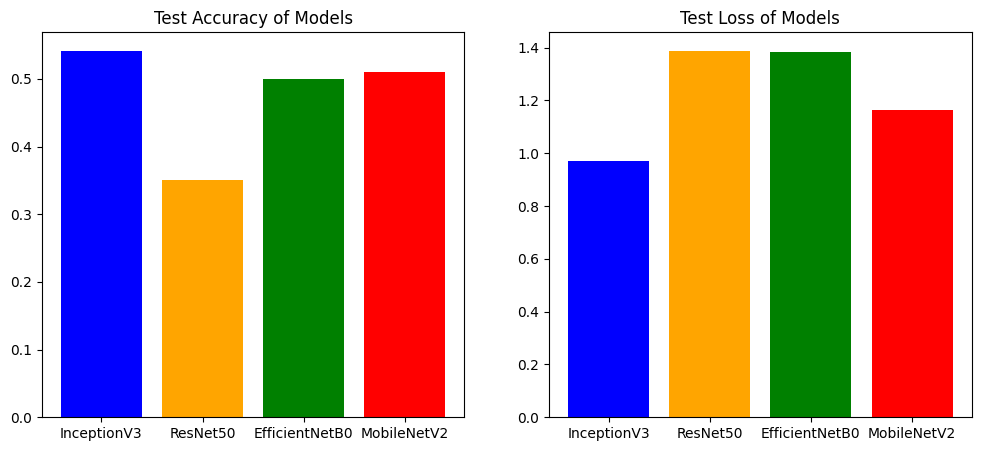

In [ ]:
#compare all 4 using graphs
import matplotlib.pyplot as plt
models = ['InceptionV3', 'ResNet50', 'EfficientNetB0', 'MobileNetV2']
accuracies = [accuracy_inception, accuracy_resnet, accuracy_efficientnet, accuracy_mobilenet]
losses = [loss_inception, loss_resnet, loss_efficientnet, loss_mobilenet]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(models, accuracies, color=['blue', 'orange', 'green', 'red'])
plt.title('Test Accuracy of Models')
plt.subplot(1, 2, 2)
plt.bar(models, losses, color=['blue', 'orange', 'green', 'red'])
plt.title('Test Loss of Models')
plt.show()

In [ ]:
aaa# train 4 models inceptionv3, resnet50, efficientnet, mobilenetv2 and compare their performance using tensorboard
#acc loss val_acc val_loss
#epoch same......

Accuracy: 0.9712


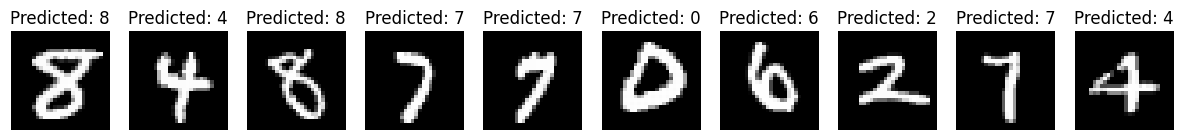

In [ ]:
#image classification with the help of ann on mnist dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data, mnist.target
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Create and train the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp.fit(X_train_scaled, y_train)
# Evaluate the model
accuracy = mlp.score(X_test_scaled, y_test)
print(f'Accuracy: {accuracy:.4f}')
# Predict on the test set
y_pred = mlp.predict(X_test_scaled)
# Visualize some predictions
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    axes[i].imshow(X_test.iloc[i].values.reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Predicted: {y_pred[i]}')
    axes[i].axis('off')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from tensorflow.keras.datasets import mnist

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


In [ ]:
model = Sequential([
    Flatten(input_shape=(28, 28)),   # 28x28 → 784

    Dense(128, activation='relu'),   # Hidden Layer 1
    Dense(64, activation='relu'),    # Hidden Layer 2

    Dense(10, activation='softmax')  # Output Layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8083 - loss: 1.5381 - val_accuracy: 0.8904 - val_loss: 0.4169
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9064 - loss: 0.3471 - val_accuracy: 0.9230 - val_loss: 0.3022
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9349 - loss: 0.2355 - val_accuracy: 0.9436 - val_loss: 0.2220
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9482 - loss: 0.1878 - val_accuracy: 0.9560 - val_loss: 0.1652
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9561 - loss: 0.1595 - val_accuracy: 0.9547 - val_loss: 0.1701
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9620 - loss: 0.1370 - val_accuracy: 0.9605 - val_loss: 0.1441
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9678 - loss: 0.1178 - val_accuracy: 0.9588 - val_loss: 0.1527
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9704 - loss: 0.1085 - 

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9609 - loss: 0.1729
Test Accuracy: 0.9609000086784363


In [ ]:
predictions = model.predict(X_test)

print("Predicted:", np.argmax(predictions[0]))
print("Actual:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted: 7
Actual: 7


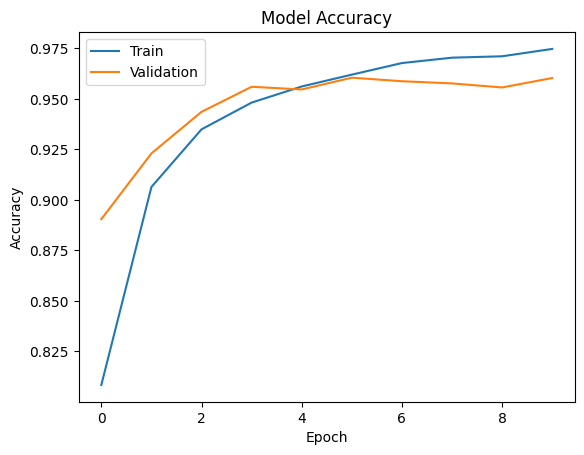

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

mnist using lenet 5

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Dense, Flatten
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
model = Sequential()

# 🔸 C1: Convolution
model.add(Conv2D(6, kernel_size=(5,5), activation='tanh', input_shape=(28,28,1)))

# 🔸 S2: Average Pooling
model.add(AveragePooling2D(pool_size=(2,2)))

# 🔸 C3: Convolution
model.add(Conv2D(16, kernel_size=(5,5), activation='tanh'))

# 🔸 S4: Average Pooling
model.add(AveragePooling2D(pool_size=(2,2)))

# 🔸 Flatten
model.add(Flatten())

# 🔸 Fully Connected Layers
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))

# 🔸 Output Layer
model.add(Dense(10, activation='softmax'))